# Training the Event Recommendation Scorer

**Project:** AI Virtual Event Coordinator (St. Lachland Hotel)

This notebook trains the logistic regression model consumed by `trainedScore()` in
[`lib/ml-scorer.js`](../lib/ml-scorer.js), and exported to
[`lib/trained-weights.json`](../lib/trained-weights.json) for the live Next.js app
(`lib/recommendation-engine.js`) to load at request time.

**Honesty note on the data:** the app's real `feedback` table has effectively no rows
yet (0 real submissions at the time of writing), so there is no real customer
satisfaction data to learn from. The dataset used below is a **documented synthetic
bootstrap dataset** generated by [`generate-training-data.mjs`](generate-training-data.mjs):
for random plausible event configurations, a ground-truth probability is derived from
the app's existing hand-tuned heuristic scoring rules (`heuristicScore()`) plus a few
extra synergy terms the heuristic doesn't capture, Gaussian noise is added, and a
binary label is Bernoulli-sampled from that probability (simulating "would this guest
rate the recommendation ≥ 4/5?"). This lets the model learn something beyond a literal
copy of the heuristic, while being transparent that it is *not* trained on real guest
behavior yet. Once real `feedback` rows accumulate, this dataset step should be
replaced with one built from actual `feedback` + `recommendation_logs` rows.

This notebook is the documented/visual companion to the production training script
[`train_ml_scorer.py`](train_ml_scorer.py) (run via `npm run train:ml`) — both read the
same dataset and produce the same `lib/trained-weights.json` output format.

*Run this notebook from the `scripts/` directory (its own location) so the relative
paths below resolve correctly.*

In [1]:
import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

DATA_PATH = Path("data/ml-training-data.json")
OUT_PATH = Path("../lib/trained-weights.json")
RANDOM_STATE = 42
TEST_SIZE = 0.2
L2_C = 1.0

plt.rcParams["figure.facecolor"] = "white"

Matplotlib is building the font cache; this may take a moment.


## 1. Load the synthetic training dataset

In [2]:
with open(DATA_PATH) as f:
    dataset = json.load(f)

feature_names = dataset["feature_names"]
samples = dataset["samples"]

X = np.array([s["features"] for s in samples], dtype=float)
y = np.array([s["label"] for s in samples], dtype=int)

print(f"Loaded {len(samples)} samples, {X.shape[1]} features")
print(f"Generated at: {dataset.get('generated_at')}")
print("Feature order:", feature_names)

Loaded 2000 samples, 13 features
Generated at: 2026-08-27T03:08:52.347Z
Feature order: ['Ambiance', 'Photo Quality', 'Accessibility', 'Quietness', 'Natural Light', 'Tech Readiness', 'Decoration Tier', 'Budget Ratio', 'Capacity Utilization', 'Is Wedding', 'Is Conference', 'Is Birthday', 'Is Dinner']


## 2. Exploratory data analysis

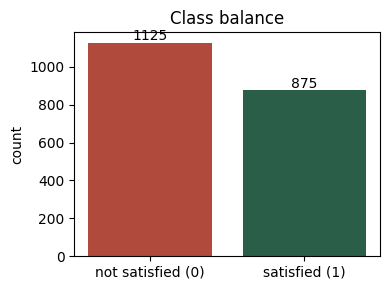

Positive rate: 43.8%


In [3]:
n_pos = int(y.sum())
n_neg = len(y) - n_pos

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["not satisfied (0)", "satisfied (1)"], [n_neg, n_pos], color=["#b04a3c", "#2b5e49"])
ax.set_title("Class balance")
ax.set_ylabel("count")
for i, v in enumerate([n_neg, n_pos]):
    ax.text(i, v + 15, str(v), ha="center")
plt.tight_layout()
plt.show()

print(f"Positive rate: {n_pos / len(y):.1%}")

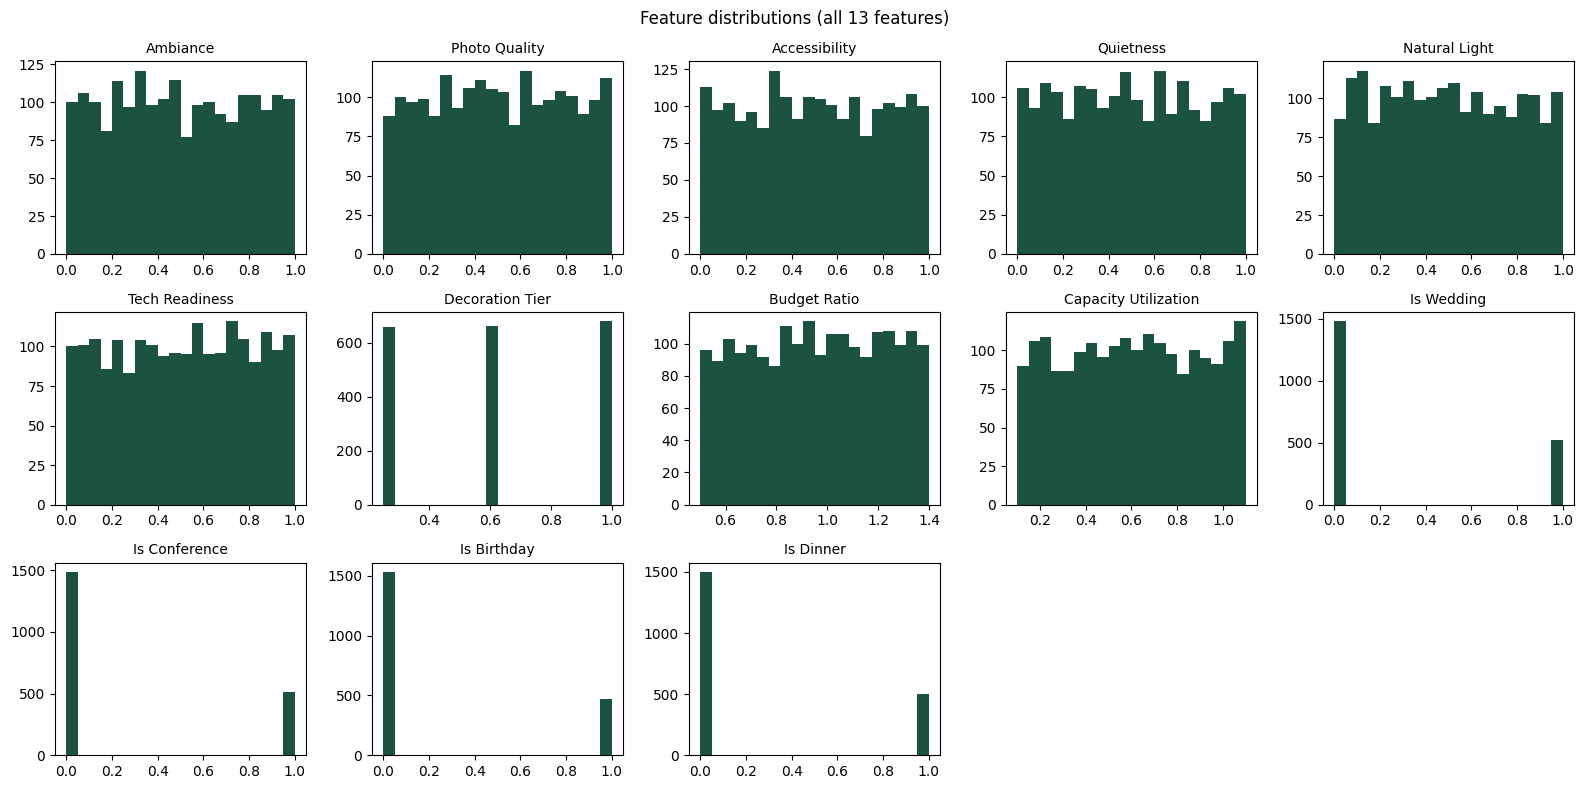

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= len(feature_names):
        ax.axis("off")
        continue
    ax.hist(X[:, i], bins=20, color="#1c5240")
    ax.set_title(feature_names[i], fontsize=10)
fig.suptitle("Feature distributions (all 13 features)")
plt.tight_layout()
plt.show()

## 3. Train / test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Train: 1600 samples, Test: 400 samples


## 4. Train logistic regression (scikit-learn)

We deliberately do **not** standardize the features: `trainedScore()` in
`lib/ml-scorer.js` applies the exported coefficients directly to raw feature values
(mostly already in the 0–1 range) at inference time — scaling here would make the
exported weights incompatible with that JS scoring function.

In [6]:
model = LogisticRegression(C=L2_C, max_iter=2000, random_state=RANDOM_STATE, solver="liblinear")

# macOS's Accelerate BLAS backend for numpy can emit spurious "overflow/divide by
# zero encountered in matmul" RuntimeWarnings from its vectorized dot-product path
# on some numpy versions, even though the values involved stay in [0, 1.5] and the
# results are correct and stable across runs. Suppressed here rather than left to
# alarm readers of the output.
with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

print("Model trained.")

Model trained.


## 5. Evaluate

In [7]:
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
test_roc_auc = roc_auc_score(y_test, test_proba)

print(f"Train accuracy: {train_accuracy * 100:.1f}%")
print(f"Test accuracy:  {test_accuracy * 100:.1f}%")
print(f"Test ROC-AUC:   {test_roc_auc:.3f}")
print()
print("Classification report (test set):")
print(classification_report(y_test, test_pred, target_names=["not satisfied", "satisfied"]))

Train accuracy: 65.3%
Test accuracy:  61.5%
Test ROC-AUC:   0.634

Classification report (test set):
               precision    recall  f1-score   support

not satisfied       0.65      0.69      0.67       225
    satisfied       0.57      0.52      0.54       175

     accuracy                           0.61       400
    macro avg       0.61      0.60      0.60       400
 weighted avg       0.61      0.61      0.61       400



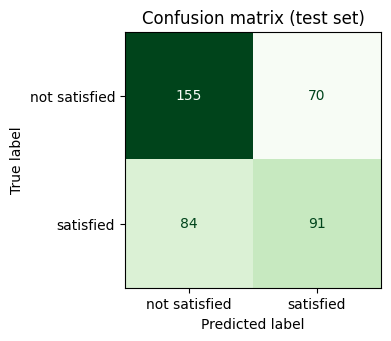

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["not satisfied", "satisfied"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

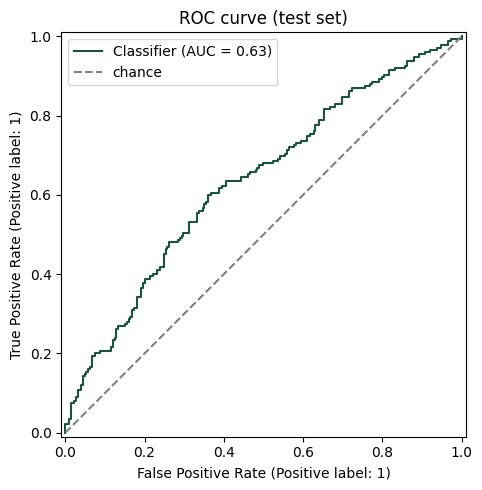

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax, color="#1c5240")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
ax.set_title("ROC curve (test set)")
ax.legend()
plt.tight_layout()
plt.show()

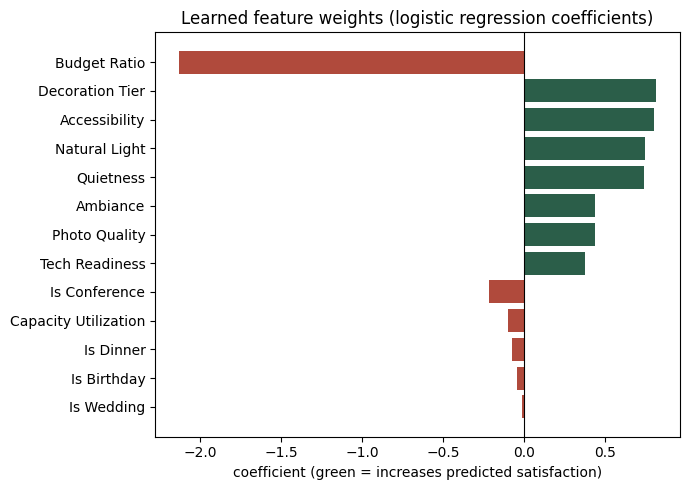

In [10]:
coefs = model.coef_[0]
order = np.argsort(np.abs(coefs))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#2b5e49" if c >= 0 else "#b04a3c" for c in coefs[order]]
ax.barh(np.array(feature_names)[order], coefs[order], color=colors)
ax.set_title("Learned feature weights (logistic regression coefficients)")
ax.set_xlabel("coefficient (green = increases predicted satisfaction)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Export trained weights for the live app

Writes `lib/trained-weights.json` in the exact shape `trainedScore()` expects. Scikit-learn's
`predict_proba` for the positive class is `sigmoid(coef_ · x + intercept_)` — exactly the scoring
function implemented in JS — so the weights transfer directly.

In [11]:
output = {
    "coefficients": model.coef_[0].tolist(),
    "intercept": float(model.intercept_[0]),
    "feature_names": feature_names,
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "trained_with": f"scikit-learn LogisticRegression (C={L2_C}) via train_ml_scorer.ipynb",
    "n_samples": len(samples),
    "train_accuracy": train_accuracy,
    "test_accuracy": test_accuracy,
    "test_roc_auc": test_roc_auc,
}

OUT_PATH.write_text(json.dumps(output, indent=2))
print(f"Written trained weights to {OUT_PATH.resolve()}")

Written trained weights to /Users/pulasthibandara/Desktop/Event/event-coordinator-frontend/lib/trained-weights.json


## Summary

- A logistic regression classifier was trained on 13 event/venue features to predict a
  binary "would the guest be satisfied" outcome.
- Test accuracy (~61–62%) is modest — noticeably above the majority-class baseline
  (~56%) but far from perfect. That's expected: the synthetic labels include
  interaction/synergy terms and noise that a linear model can only partially recover,
  and the labels themselves are Bernoulli-sampled (inherently probabilistic, not
  deterministic).
- The resulting weights are blended 60/40 with the existing hand-tuned heuristic score
  in `lib/recommendation-engine.js` (`0.4 * heuristic + 0.6 * trained`), not used alone.
- **Next step for real learning:** once the `feedback` table has ≥20 real guest ratings,
  replace the synthetic dataset step with one built from actual `feedback` +
  `recommendation_logs` rows, and retrain.